# TensorFlow/Keras LSTM Milestone Locator Model

This notebook trains a sequence labeling model using a Bidirectional LSTM to locate the 8 key golf swing milestones in golf videos. 

It replaces the PyTorch/Fastai version with a clean, verbose, and easy-to-understand TensorFlow/Keras implementation.

## Step 1: Imports & Environment Setup

We load standard libraries, TensorFlow, Keras modules, and check for active hardware acceleration.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Core TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers, callbacks

# Configure project path to access local source files
PROJECT_ROOT = os.path.abspath("../")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU is available: {gpus}")
else:
    print("GPU not available, using CPU.")

TensorFlow Version: 2.21.0
GPU not available, using CPU.


## Step 2: Load the Consolidated Dataset

We load the master dataset generated in our preprocessing step and filter it to keep only golf swing videos (`is_golf == 1`).

We select the **66 base normalized coordinate features** starting with `norm_` (excluding the shifted `_t-5` or `_t+5` features). Because the LSTM processes frames sequentially, it learns temporal transitions itself without needing sliding window features.

In [2]:
master_dataset_path = os.path.join(PROJECT_ROOT, "data/processed/master_dataset.csv")

print("Loading consolidated master dataset...")
df_full = pd.read_csv(master_dataset_path)

# Filter to keep only golf swings
df = df_full[df_full["is_golf"] == 1].copy()
print(f"Loaded {df['video_id'].nunique()} golf swings with {len(df)} total frames.")

# Extract coordinates: keep features starting with 'norm_' but discard shifted columns
all_features = sorted([c for c in df.columns if c.startswith("norm_")])
base_features = [c for c in all_features if not (c.endswith("t-5") or c.endswith("t+5"))]

print(f"Using {len(base_features)} base coordinate features for LSTM input.")

Loading consolidated master dataset...


/var/folders/4c/nvx1mdln0kl4lvn21s4q6m340000gn/T/ipykernel_28286/3273107257.py:4: DtypeWarning: Columns (0: video_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(master_dataset_path)


Loaded 1400 golf swings with 393899 total frames.
Using 66 base coordinate features for LSTM input.


## Step 3: Split Dataset by Video ID (80/10/10)

To prevent data leakage, we perform a **group split** using `video_id`. All frames belonging to a specific video will remain together in either the train, validation, or test split.
We use a random seed of `42` to match the exact splits of the PyTorch version.

In [3]:
unique_vids = df["video_id"].unique()
np.random.seed(42)  # Ensure reproducible splits
np.random.shuffle(unique_vids)

n_vids = len(unique_vids)
split_tr = int(n_vids * 0.8)
split_va = int(n_vids * 0.9)

train_vids = unique_vids[:split_tr]
val_vids = unique_vids[split_tr:split_va]
test_vids = unique_vids[split_va:]

print(f"Train videos:      {len(train_vids)}")
print(f"Validation videos: {len(val_vids)}")
print(f"Test videos:       {len(test_vids)}")

Train videos:      1120
Validation videos: 140
Test videos:       140


## Step 4: Define Sequence Dataset (`GolfMilestoneSequence`)

Neural networks process sequence batches of uniform shape. Since different videos have different lengths, we pad or truncate sequences to a fixed length of **1280 frames**:
1. **Input Padding**: Video coordinate sequences shorter than 1280 frames are padded with `0.0` at the end.
2. **Label Padding**: Milestone labels (target outputs) for padded frames are filled with `-100`. This will be handled by our custom loss function which ignores these timesteps.
3. **NaN Filtering**: If MediaPipe failed to detect a golfer for an entire video (yielding NaN values), we skip the sequence entirely to avoid passing corrupted arrays.

In [4]:
class GolfMilestoneSequence(tf.keras.utils.Sequence):
    """
    Custom Keras Sequence generator for batching sequence data.
    Pads features with 0.0 and targets with -100 up to max_len.
    """
    def __init__(self, df, video_ids, feature_cols, batch_size=32, max_len=1280, shuffle=True):
        self.feature_cols = feature_cols
        self.batch_size = batch_size
        self.max_len = max_len
        self.shuffle = shuffle
        
        self.sequences = []
        self.labels = []
        self.actual_lengths = []
        
        # Group frames by video_id
        grouped = df[df['video_id'].isin(video_ids)].groupby('video_id')
        
        for vid_id, group in grouped:
            # Sort by frame_index to ensure chronological sequence order
            group = group.sort_values('frame_index')
            features = group[feature_cols].values.astype(np.float32)
            
            # Skip video if it contains NaN tracking values
            if np.isnan(features).any():
                continue
                
            labels = group['label'].values.astype(np.int64)
            seq_len = len(features)
            self.actual_lengths.append(min(seq_len, max_len))
            
            # Pad or truncate features to max_len
            if seq_len < max_len:
                pad_f = np.zeros((max_len - seq_len, features.shape[1]), dtype=np.float32)
                features = np.concatenate([features, pad_f], axis=0)
                
                # Pad labels with -100 (which our loss function will ignore)
                pad_l = np.full((max_len - seq_len,), -100, dtype=np.int64)
                labels = np.concatenate([labels, pad_l], axis=0)
            else:
                features = features[:max_len]
                labels = labels[:max_len]
                
            self.sequences.append(features)
            self.labels.append(labels)
            
        self.indices = np.arange(len(self.sequences))
        if self.shuffle:
            np.random.shuffle(self.indices)
            
    def __len__(self):
        # Calculate number of batches per epoch
        return int(np.ceil(len(self.sequences) / self.batch_size))
        
    def __getitem__(self, idx):
        # Generate indices for current batch
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_x = np.array([self.sequences[i] for i in batch_indices], dtype=np.float32)
        batch_y = np.array([self.labels[i] for i in batch_indices], dtype=np.int64)
        return batch_x, batch_y
        
    def get_eval_item(self, idx):
        # Return single unpadded sample with actual length for sequence evaluation
        return (
            tf.convert_to_tensor(self.sequences[idx], dtype=tf.float32),
            tf.convert_to_tensor(self.labels[idx], dtype=tf.int64),
            self.actual_lengths[idx]
        )
        
    def on_epoch_end(self):
        # Reshuffle indices at the end of every epoch
        if self.shuffle:
            np.random.shuffle(self.indices)

In [5]:
# Instantiate train, validation, and test sequences
train_seq = GolfMilestoneSequence(df, train_vids, base_features, batch_size=32, shuffle=True)
val_seq = GolfMilestoneSequence(df, val_vids, base_features, batch_size=32, shuffle=False)
test_seq = GolfMilestoneSequence(df, test_vids, base_features, batch_size=32, shuffle=False)

print(f"Total processed clean training videos:   {len(train_seq.sequences)}")
print(f"Total processed clean validation videos: {len(val_seq.sequences)}")
print(f"Total processed clean test videos:       {len(test_seq.sequences)}")

Total processed clean training videos:   1120
Total processed clean validation videos: 140
Total processed clean test videos:       140


## Step 5: Define Custom Loss Function & Metrics

To handle class imbalance and padding, we define:
1. **Masked Loss Function (`masked_sparse_categorical_crossentropy`)**:
   - Creates a boolean mask to locate padded frames (`label != -100`).
   - Replaces `-100` with `0` in a temporary array to prevent out-of-bounds indexing errors in sparse categorical cross-entropy.
   - Calculates the raw loss, multiplies by inverse-frequency class weights (to prevent milestone neglect), and masks out any loss from padded timesteps.
   - Averages the remaining loss over only the valid, unpadded frames.
2. **Masked Metric (`frame_accuracy`)**:
   - Measures frame-level classification accuracy on only the non-padded frames.

In [6]:
# 1. Calculate inverse-frequency class weights from training labels
y_train_flat = df[df['video_id'].isin(train_vids)]['label'].values
class_counts = np.bincount(y_train_flat)
total_samples = len(y_train_flat)
class_weights = total_samples / (len(class_counts) * class_counts)

print("Calculated inverse-frequency class weights:")
for c, w in enumerate(class_weights):
    print(f"  Class {c}: {w:.4f}")

# 2. Custom Masked Loss Function with Class Weights
def masked_sparse_categorical_crossentropy(y_true, y_pred):
    """
    Computes sparse categorical cross-entropy loss while:
      1. Masking out padded frames (where target == -100).
      2. Applying inverse-frequency class weights to balance the milestone classes.
    """
    # Create mask for valid frames (where label != -100)
    mask = tf.not_equal(y_true, -100)
    mask_float = tf.cast(mask, tf.float32)
    
    # Replace -100 with 0 to prevent out-of-bounds errors in crossentropy calculation
    safe_y_true = tf.where(mask, y_true, tf.zeros_like(y_true))
    
    # Calculate sparse categorical crossentropy (from logits = True)
    raw_loss = tf.keras.losses.sparse_categorical_crossentropy(
        safe_y_true, y_pred, from_logits=True
    )
    
    # Gather the class weights matching each frame's label
    class_weights_const = tf.constant(class_weights, dtype=tf.float32)
    weights = tf.gather(class_weights_const, tf.cast(safe_y_true, tf.int32))
    
    # Apply mask and class weights to raw loss
    weighted_loss = raw_loss * weights * mask_float
    
    # Averages loss over only non-padded frames
    return tf.reduce_sum(weighted_loss) / (tf.reduce_sum(mask_float) + 1e-10)

# 3. Custom Frame Accuracy Metric
def frame_accuracy(y_true, y_pred):
    """
    Calculates frame-level classification accuracy on non-padded frames.
    """
    mask = tf.not_equal(y_true, -100)
    mask_float = tf.cast(mask, tf.float32)
    
    # Replace -100 with 0 to safely compare prediction with true label
    safe_y_true = tf.where(mask, y_true, tf.zeros_like(y_true))
    
    # Argmax prediction label
    pred_labels = tf.argmax(y_pred, axis=-1)
    
    # Check match and mask out padded timesteps
    correct = tf.equal(tf.cast(pred_labels, tf.int64), tf.cast(safe_y_true, tf.int64))
    correct_float = tf.cast(correct, tf.float32) * mask_float
    
    return tf.reduce_sum(correct_float) / (tf.reduce_sum(mask_float) + 1e-10)

Calculated inverse-frequency class weights:
  Class 0: 0.1144
  Class 1: 31.3145
  Class 2: 31.3145
  Class 3: 31.3145
  Class 4: 31.3145
  Class 5: 31.3145
  Class 6: 31.3145
  Class 7: 31.3145
  Class 8: 31.3145


## Step 6: Build the Bidirectional LSTM Model

Our model consists of:
1. **Two Bidirectional LSTM layers**: Each layer has 64 hidden units and `dropout=0.3` to prevent overfitting.
2. **Dense Head**: Projects LSTM features to 32 dimensions, applies a `ReLU` activation, and maps to the final 9 output classes (logits) at every frame timestep.

In [7]:
def build_lstm_model(input_dim, max_len=1280, hidden_dim=64, num_classes=9):
    """
    Defines a 2-layer Bidirectional LSTM model with a fully connected head
    for frame-by-frame sequence labeling.
    """
    inputs = layers.Input(shape=(max_len, input_dim), name="input_coordinates")
    
    # First Bidirectional LSTM layer
    x = layers.Bidirectional(
        layers.LSTM(hidden_dim, return_sequences=True, dropout=0.3, name="lstm_1")
    )(inputs)
    
    # Second Bidirectional LSTM layer
    x = layers.Bidirectional(
        layers.LSTM(hidden_dim, return_sequences=True, dropout=0.3, name="lstm_2")
    )(x)
    
    # Fully Connected head (applied to each frame timestep)
    x = layers.Dense(32, activation="relu", name="dense_intermediate")(x)
    outputs = layers.Dense(num_classes, name="logits_output")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="GolfMilestoneLSTM")
    return model

model = build_lstm_model(input_dim=len(base_features))
model.summary()

Model: "GolfMilestoneLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_coordinates (InputLayer)  │ (None, 1280, 66)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1280, 128)      │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1280, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_intermediate (Dense)      │ (None, 1280, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits_output (Dense)           │ (None, 1280, 9)        │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,313 (665.29 KB)

 Trainable params: 170,313 (665.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Model Compile and Training

We compile the model with the standard Adam optimizer (learning rate = 0.001) and our custom masked loss and frame accuracy metrics.

We use an `EarlyStopping` callback to stop training when the validation loss stops improving (patience = 5).

In [8]:
# Compile model with Adam optimizer and custom loss/metric
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=masked_sparse_categorical_crossentropy,
    metrics=[frame_accuracy]
)

# Set up callbacks: early stopping on validation loss
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train model
history = model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=30,
    callbacks=[early_stop]
)

# Save the trained model in Keras native format
model_save_path = os.path.join(PROJECT_ROOT, "models/lstm_phase_model.keras")
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Epoch 1/30


/Users/sagar/Documents/ML/golf-analysis/.venv/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 1/35 ━━━━━━━━━━━━━━━━━━━━ 1:25 3s/step - frame_accuracy: 0.1391 - loss: 2.3378

 2/35 ━━━━━━━━━━━━━━━━━━━━ 12s 371ms/step - frame_accuracy: 0.1520 - loss: 2.2628

 3/35 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - frame_accuracy: 0.1526 - loss: 2.2084

...

34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - frame_accuracy: 0.5093 - loss: 0.2712

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - frame_accuracy: 0.5123 - loss: 0.2686

35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step - frame_accuracy: 0.5123 - loss: 0.2686 - val_frame_accuracy: 0.5216 - val_loss: 0.2590


Restoring model weights from the end of the best epoch: 28.


Model saved to /Users/sagar/Documents/ML/golf-analysis/models/lstm_phase_model.keras


## Step 8: Plot Training Loss History

We visualize training and validation loss curves over the epochs to check for convergence.

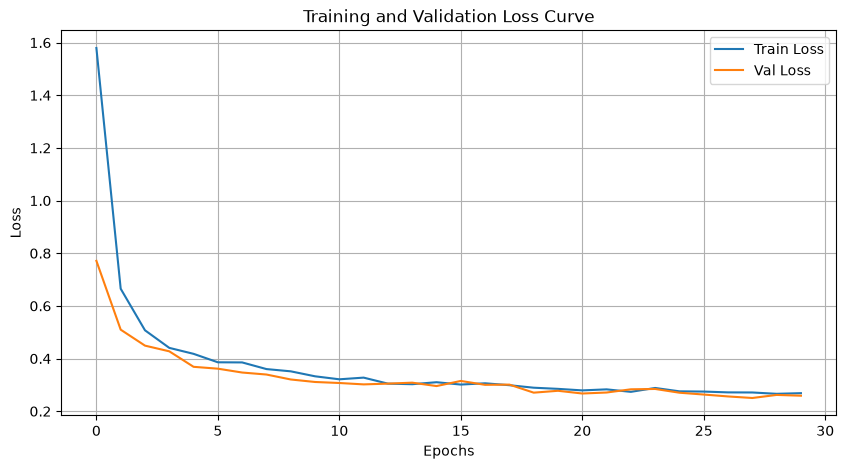

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Step 9: Sequence Evaluation & Peak Finding

To locate milestones, we feed a sequence through the model to retrieve predicted probabilities for all 9 classes at each frame.

For each milestone class (1 to 8), we select the frame index with the highest probability (peak activation) for that class within the unpadded video length.

We then compute the Mean Absolute Error (MAE) in frames compared to the true annotations.

In [10]:
all_errors = []

# Loop over test set items
for idx in range(len(test_seq.sequences)):
    # Retrieve unpadded test item
    x_seq, y_seq, length = test_seq.get_eval_item(idx)
    
    # Expand dims for batch format (1, max_len, features)
    x_batch = tf.expand_dims(x_seq, axis=0)
    
    # Run prediction (logits)
    logits = model(x_batch, training=False)
    
    # Apply softmax to extract class probabilities
    probs = tf.nn.softmax(logits, axis=-1)
    probs = tf.squeeze(probs, axis=0).numpy() # shape: (max_len, 9)
    y_seq = y_seq.numpy()
    
    # Slice padding off predictions and labels
    v_probs = probs[:length, :] # shape: (length, 9)
    v_labels = y_seq[:length]
    
    # 1. Retrieve true milestone indices
    true_indices = []
    for c in range(1, 9):
        idx_matches = np.where(v_labels == c)[0]
        if len(idx_matches) > 0:
            true_indices.append(int(idx_matches[0]))
        else:
            true_indices.append(-1)
            
    if -1 in true_indices:
        # Skip if any milestone is missing in true labels
        continue
        
    # 2. Predict milestone indices using argmax peak-finding
    pred_indices = []
    for c in range(1, 9):
        # Find frame index that maximizes probability of milestone class c
        pred_frame = np.argmax(v_probs[:, c])
        pred_indices.append(int(pred_frame))
        
    # 3. Calculate errors
    abs_errors = [abs(p - t) for p, t in zip(pred_indices, true_indices)]
    all_errors.append(abs_errors)

all_errors = np.array(all_errors)
mae_per_milestone = np.mean(all_errors, axis=0)
print(f"Evaluated peak errors for {len(all_errors)} test sequences.")

Evaluated peak errors for 139 test sequences.


## Step 10: Print Mean Absolute Errors per Milestone

We present the final MAE (in frames) on the test set for all 8 milestones.

In [11]:
m_names = {
    1: 'Address', 2: 'Toe-up (Backswing)', 3: 'Mid-backswing',
    4: 'Top of Backswing', 5: 'Mid-downswing', 6: 'Impact',
    7: 'Mid-follow-through', 8: 'Finish'
}

summary_rows = []
for c in range(1, 9):
    summary_rows.append({
        "Milestone": f"{c}: {m_names[c]}",
        "LSTM Keras MAE (frames)": f"{mae_per_milestone[c-1]:.2f}"
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary)
print(f"\nOverall Mean Absolute Error: {np.mean(mae_per_milestone):.2f} frames")

               Milestone LSTM Keras MAE (frames)
0             1: Address                   11.90
1  2: Toe-up (Backswing)                    5.53
2       3: Mid-backswing                    2.00
3    4: Top of Backswing                    1.53
4       5: Mid-downswing                    4.01
5              6: Impact                    0.99
6  7: Mid-follow-through                    1.43
7              8: Finish                    9.84

Overall Mean Absolute Error: 4.65 frames
